<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic1.3-Linear_Regression/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Linear Regression

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic1.3-Linear_Regression_Problems.zip) <archives/Topic1.3-Linear_Regression_Problems.zip>` — the notebook and
`methanol_IR.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Linear Regression </1-numerical_methods/Topic1.3-Linear_Regression>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::

## Setup

The chapter fit basis functions to an **ethanol** infrared spectrum. Here you will work
with a **methanol** spectrum measured under different conditions: gas phase, 70 mmHg of
methanol in nitrogen to 600 mmHg total, 5 cm path length, 2 cm⁻¹ resolution. It comes
from the Coblentz Society collection in the NIST Chemistry WebBook (spectrum 8791,
measured at Dow Chemical in 1964), converted from transmittance to absorbance by
$A = -\log_{10} T$.

Methanol is the simplest alcohol, so its spectrum is a stripped-down version of
ethanol's: a strong C–O stretch near 1030 cm⁻¹ and a cluster of C–H stretches between
2800 and 3050 cm⁻¹, without ethanol's extra methylene modes. That makes it a good place
to ask how many basis functions a band actually needs.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/methanol_IR.csv')
x_all = df['wavenumber [cm^-1]'].values
y_all = df['absorbance'].values
print(f"{len(x_all)} points, {x_all.min():.1f}-{x_all.max():.1f} cm^-1")

3567 points, 463.4-3806.6 cm^-1


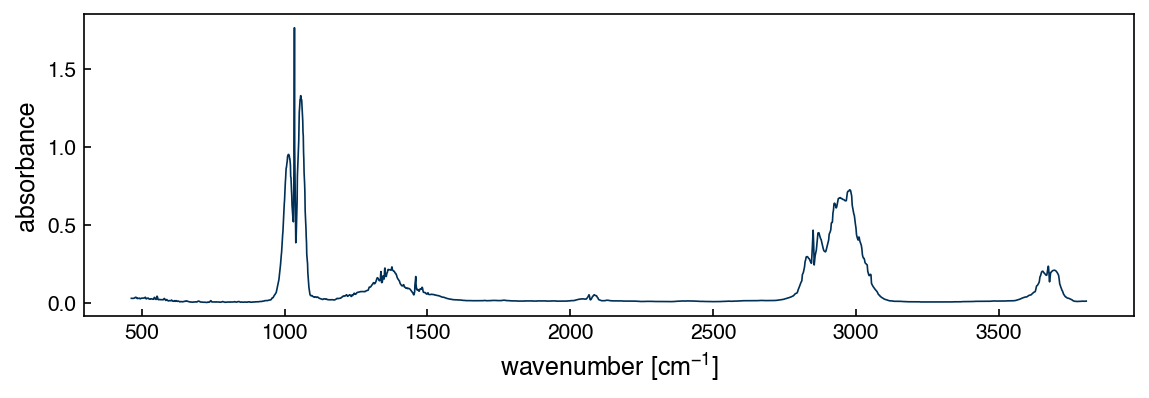

In [2]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x_all, y_all, lw=0.8)
ax.set_xlabel('wavenumber [cm$^{-1}$]')
ax.set_ylabel('absorbance');

Run this once to load the autograder. It will not run inside the book — use the
downloaded notebook.

In [ ]:
import otter
grader = otter.Notebook()

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each. Each asks you to assign a single number to a named
variable. Run the check cell after each one; there is no limit on attempts.

### A1. Locate the C–O stretch (10 pts)

:::{exercise}
:label: pr-nm-meoh-co-peak

Restrict the spectrum to the window $950 \le \tilde\nu \le 1120$ cm⁻¹, which contains the
C–O stretch and its two shoulders. Find the wavenumber at which absorbance is largest in
that window.

Assign the wavenumber in cm⁻¹ to `peak_wavenumber`.
:::

In [ ]:
# YOUR CODE HERE
peak_wavenumber = ...

In [ ]:
grader.check("q1")

### A2. Fit one Gaussian to the band (10 pts)

:::{exercise}
:label: pr-nm-meoh-gauss-fit

Model the same window as a single Gaussian sitting on a flat baseline:

$$
A(\tilde\nu) \;=\; w_0 \exp\!\left[-\frac{(\tilde\nu - c)^2}{2\sigma^2}\right] + w_1
$$

with the center $c$ fixed at your answer from A1 and $\sigma = 25$ cm⁻¹ (the same width
the chapter used). Build the two-column design matrix $\bar{\bar{X}}$ — one column for the
Gaussian, one of ones for the baseline — and solve the normal equations
$\bar{\bar{X}}^T\bar{\bar{X}}\vec{w} = \bar{\bar{X}}^T\vec{y}$ with `np.linalg.solve`.

Assign the Gaussian coefficient $w_0$ to `w_gauss`.
:::

In [ ]:
# YOUR CODE HERE
w_gauss = ...

In [ ]:
grader.check("q2")

### A3. Score the fit (10 pts)

:::{exercise}
:label: pr-nm-meoh-fit-r2

Compute the coefficient of determination for the A2 fit **over the same window**:

$$
r^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

Assign it to `r2_single`.
:::

In [ ]:
# YOUR CODE HERE
r2_single = ...

In [ ]:
grader.check("q3")

---


## Part B — Visualization (35 pts)

:::{exercise}
:label: pr-nm-meoh-basis-tune

One Gaussian recovered only $r^2 = 0.65$. Stay in the **same 950–1120 cm⁻¹ window** and
find out what it actually takes to describe this band, using the two basis families from
the chapter.

**1. Polynomials.** Fit `np.vander(x_band - x_band.mean(), order + 1)` by least squares for
`order = 2, 4, 6, 8, 10, 12`. For each, record $r^2$ **and** the condition number of
$\bar{\bar{X}}^T\bar{\bar{X}}$ (`np.linalg.cond`). Plot the data with the best two fits
overlaid.

**2. Gaussians, tuned by hand.** Build a design matrix whose columns are Gaussians plus a
column of ones, as in A2 — but now *you* choose each center $c_j$ and width $\sigma_j$.
Only the amplitudes come from least squares, so this is still a linear fit; the centers
and widths are yours to place.

Work up from `N = 1` to `N = 6` components. For each `N`, position and widen the Gaussians
by eye until the fit tracks the data as well as you can get it, then record $r^2$ and the
condition number. Say in one line what you were trying to do with each new component.

**3. Plot.** Data with your `N = 1`, `N = 3` and `N = 6` fits overlaid, and beneath it, on
shared x-axes, the residuals for those three.

**4. Interpret**, in **4–6 sentences**:

- The polynomial $r^2$ rises and then collapses, eventually going *negative*. Explain what
  causes that, using your condition numbers. It is not overfitting.
- The Gaussian condition numbers stay small no matter how many components you add. Why is
  this basis so much better behaved for this band?
- Your Gaussian $r^2$ should jump sharply somewhere and then nearly flatten. Where, and
  what feature of the spectrum does that tell you about?

Label your axes with units.
:::

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots()

---

## Part C — Open Ended (35 pts)

Real absorption lines are not Gaussian. Two broadening mechanisms act at once:

- **Doppler and instrumental broadening** are the sum of many small independent effects, so
  by the central limit theorem they give a **Gaussian** profile of width $\sigma$.
- **Collisional (pressure) broadening and finite excited-state lifetime** give a
  **Lorentzian** profile of half-width $\gamma$, which has far heavier wings than a Gaussian.

Both act, so the true line shape is their convolution — the **Voigt profile**:

$$
V(\tilde\nu;\sigma,\gamma) \;=\; \int_{-\infty}^{\infty}
G(\tilde\nu';\sigma)\, L(\tilde\nu-\tilde\nu';\gamma)\, \mathrm{d}\tilde\nu'
$$

It has no closed form in elementary functions, but `scipy.special.voigt_profile(x, sigma,
gamma)` evaluates it directly. Setting $\gamma = 0$ recovers a Gaussian and $\sigma \to 0$
recovers a Lorentzian, so the Voigt profile contains both of Part B's shapes as limits.

One thing changes about the fitting. A Gaussian's amplitude is linear in the model, so
Part B's amplitudes came from `np.linalg.solve`. A Voigt's $\sigma$ and $\gamma$ are **not**
linear, so a least-squares solve cannot find them — you need a nonlinear optimizer such as
`scipy.optimize.curve_fit`, which needs starting guesses and can converge to nonsense if
they are poor. Give it bounds and sensible starting values.

:::{exercise}
:label: pr-nm-meoh-voigt-peaks

Fit sums of $N$ Voigt profiles to the same 950–1120 cm⁻¹ window with `curve_fit`, for
`N = 1, 2, 3` and at least one larger `N`. Each component contributes
$A_j\,V(\tilde\nu - c_j;\sigma_j,\gamma_j)$, so there are four parameters per component.
Seed the centers from the maxima you already know and bound them so they cannot wander.

Then answer the question this whole problem set has been building toward:

**How many distinct peaks are in this window?**

Support your answer with:

1. $r^2$ versus $N$ for the Voigt fits, compared against your Part B Gaussian results at
   the same $N$.
2. The fitted parameters of your best model — center, width and area of each component.
   Look at them carefully; they are not all alike.
3. Evidence that your chosen $N$ is not just the largest one you tried: show what the next
   component buys, and check the fit is stable when you change the starting guesses.
4. A short written argument (**one paragraph**). Does "number of peaks" mean the number of
   resolved maxima, the number of components a model needs, or the number of distinct
   molecular vibrations? They need not be the same number, and saying so with evidence is a
   better answer than picking one.

There is more than one defensible answer here. You are graded on the reasoning and the
evidence.
:::

In [ ]:
# YOUR CODE HERE
from scipy.special import voigt_profile
from scipy.optimize import curve_fit

---

## Summary

- Part A fit a single Gaussian to the C–O stretch band by solving the normal equations
  directly, and scored $r^2 = 0.65$ — enough to show the method works, not enough to
  describe the band.
- Part B set two basis families against each other on that same band. Polynomials fail
  numerically before they fit well, their condition number crossing the limit of double
  precision by order 6; a Gaussian basis stays well conditioned however many components are
  added, and its $r^2$ saturates once there is one component per resolved maximum.
- Part C replaced the line shape with a Voigt profile, which needs a nonlinear fit but
  reaches $r^2 = 0.994$ with three components — and whose fitted parameters say more about
  the molecule than the fit quality does.

## Additional Reading

1. NIST Chemistry WebBook, SRD 69 — [methanol IR spectrum](https://webbook.nist.gov/cgi/cbook.cgi?ID=C67561&Type=IR-SPEC),
   Coblentz Society collection no. 8791.
2. [`scipy.special.voigt_profile`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.voigt_profile.html)
   and [`scipy.optimize.curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html).
3. [`numpy.linalg.cond`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html)
   — the diagnostic that explains Part B's polynomial collapse.